AUTOENCODER: LOGFICA DI CODIFICA/DECODIFICA

Costruire una macchina che impara a copiare se stessa.
Ma negli autoencoder la copia non è l'obbiettivo, e solo il pretesto, obbiettivo vero è imparare a dimanticare il superfluo per ricordare solo l'essenziale.
Come quando ascolti un lungo racconto e poi devi riassumerlo in una frase, quella frase è l'essenza del dato

Vedremo come comprimiamo l'inforazione?

Un autoencode è una rete neuroale che impara a comprimere un dato e poi a ricostruirlo. La logica è molto semplice:
intup -> encoder -> rappresentazione compressa -> decoder -> ristostruzione dell'input
L'obbiettivo non è classificare il dato. E' riuscire a ricostruirlo perdendo il meno possibile di informazione.
Prendiamo un esempio, hai questo vettore:
[10,12,11,9,10,11]
l'encoder potrebbe trasformarlo in una rappresentazione più piccola:
[10.5,1.1]
Il decoder usa quei due valori per ricostruire qualcosa del tipo:
[10.1,11.8,10.9,9.3,10.2,10.8]
Il modello è stasto costretto a passare da 6 valori a 2. Quindi deve imparare quali informazioni vale la pena ricordare.
Quella zona comopressa viene chiamata:
Latent space, oppure spazio latente
Input: 100 variabili
-
Encoder
-
Latent space: 10 variabili
-
Decoder
-
Output: 100 variabili
L'Encoder quindi tra x trova z z (x=dato originale z=rappresentazione latente)
il Decoder da z deve trovare una ricostruzione di x
L'intero autoencoder fa da x a qualcosa di simile a x

Nel training input e target sono lo stesso dato
x=immagine di gatto y=immagine di gatto
in Keras qualcosa del tipo:
autoencoder,fit(x_train,x_train)
Stai dicendo al modello prendi x, comprimilo e cerca di ricostruirlo
La loss misura quando la ricostruzione è diversa dall'originale
Per dati numerici è frequente usare MSE

input originale -> autoencoder -> confronto con originale -> errore -> aggiornameto pesi

Più il training procede, più il modello cerca di ridurre l'errore.

Il punto principale è il collo di bottiglia, cioè il numero di variabili che l'encoder deve tradurre.
Qusto collo di bottiglia, detto bottleneck, fa perdere informazioni
Se il bottleneck è abbastanza piccolo, il modello non può semplicemente copiare tutto. Deve trovare una rappresentazione compatta.
Ed è qui che l'autoencoder diventa interessante.

Il collo di bottiglia serve anche a restringere il flusso di informazioni per estrarre solo i tratti salienti dell'input
Si tratta di apprendimento non supervisionato, non servono etichette, servono solo dati stessi.

Il successo del modello dipende dalla capacità di mantenere le informazioni critiche scartando il rumore superfluo.
Se il decoder riesce a ricostruire bene l'immagine, significa che l'encoder ha preso ottimi appunti

Supponiamo migliaia di immagini di volti
non gli diciamo questo ha gli occhiali, questo è frontale, questo ha capelli scuri.
Ma per ricostruire bene i volti, l'encoder deve imparare rappresentazioni utili di caratteristiche come: forma del viso, posizione degli occhi, orientamente, luminosità, ecc
Non significa però che una dimensione latente corrisponde necessariamente in modo pulito a: capelli, occhi, età, ecc
Questa è una semplificazione per far comprendere il concetto. In un autoencoder normale lo spazio latente può essere poco interpretabile.
Questo ci porta a un'altra distinzione importante
Un autoencoder classico non è automaticamente un modello generativo

Questo è il cuore del faeture learning

Flusso della Ricostruzione
Il flusso inizia con il Mapping di Input. L'input attraversa strati densi o convoluzionali che ne riducono strato dopo strato la dimensionalità
La rappresentazione latente è il punto centrale della rete dove il dato risiede nella sua forma più astratta e densa.
Il decoder specchia l'encoder per riportare il vettore latente alla dimensione spaziale originale.

Ma deve sempre essere perfatta la ricostruzione?

Sebbene molti autoencoder siano simmetrici (x e y sono identici), in realtà l'importante è che la capacità del decoder sia sufficiente a interpretare lo spazio latente creato dal encoder.
Questa struttura getta le basi per modelli più complessi (modelli generativi più avanzati) che vedremo nei prossimi moduli, come VAE

Ora spostiamoci nella zona più stratta, il collo di bottiglia

Il Collo di Bottiglia (Bottleneck)
Il cuore della compressione informativa
Il collo di bottiglia è l'elemento restrittivo che impedisce alla rete di impoarare semplicemente a copiare l'input in output.
Senza questo limite, la rete imparerebbe la funzione identità, diventando un sistema di memorizzazione inutile per l'estrazione delle feature.
Il collo di bottiglia è l'ostacolo che costringe la rete a trovare delle scorciatoie intelligenti, insomma delle feature che ne riassumano il contenuto.

In che modo questo limite forzato aiuta l'inteligenza artificiale.

Ridurre il numero di neuroni al centro, è come costringere qualcuno a descrivere un file usando solo 3 parole. In questo modo forziamo la rete a trovare una sintesi effciente.
Le feature apprese nel bottleneck rappresentano le variazioni più importanti presenti nel dataset.
Il bottleneck agisce come un regolarizzatore naturale che previene l'overfitting sui dettagli insignificativi
Lo spazio latente h cattura le variabili latente che governano la generazione dei dati osservati.
h agisce come un regolarizzatore, il rumore casuale non può passare attraverso un varco così stretto, solo i valori costanti e ripetitivi del dato riescono a passare.

Questo processo ci ricorda una tecnica statistica: Undercomplete Autoencoder

Undercomplete Autoencoders
Concettualmente sono simili alla PCA (analisi delle componenti principali) ma con il superpotere della non linearità. Mentra la PCA può solo tracciare linee rette nello spazio dei dati, l'autoencoder può curvare nello spazio per trovare le feature migliori.
Se bottleneck è troppo piccolo perdiamo dettagli importanti
Se è troppo grande la compressione svanisce a la rete smette di imparare. 

Ma cosa rappresenta davvero quel piccolo vettori di numeri al centro?

Il ruolo del Codice Latente
Estrarre l'essenza del dato
il dato viene spogliato della sua forma grezza per diventare un vettore matematico denso di significato semantico.
Questo concetto è fondamentale per la generazione di nuovi campioni.

Ma come facciamo a dire alla rete se la sua ricostruzione è buona o pessima?

Funzione di perdita: MSE
Quantificare la qualità della ricostruzione
Per addestrare un Autoencoder, dobbiamo misurare quanto l'output differisce all'input originale tramite una funzione di costo specifica.
Useremo l'errore quadratico medio per penalizzare le discrepanze pixel per pixel tra il dato reale e quello ricostruito.

Mean Squared Errore (MSE)
La guida per la backpropagation
- L'errore quadratico medio calcola la media dei quadrati delle differenze tra input e ricostruzione. La eleviamo al quadrato per dare peso ai valori più grandi (grandi differenze) e poi facciamo la media
- Questa loss è differenziabile, permettendo l'uso delle discesa del gradiente per aggiornare i pesi di encoder e decoder.
- Un valore basso di MSE indica che la rete è riuscita a comprimere e decomprimere il dato con successo.
- L'obbiettivo dell'ottimizzazione è minimizzare questa discrepanza su tutto il dataset di apprendimento.

Ci dice in quale direzione muovere i pesi della rete per migliorare la prossima volta.

Ma come avviene questo miglioramento durante l'addestramento?

Dinamiche di Addestramento
L'addestramento è una danza iterativa chiamata grazien descent. a ogni passo calcoliamo la loss e aggirniamo i parametri 'theta' di tutta la clessidra.
- Gradient Descent: il processo iterativo che riduce la loss modificando i parametri 'theta' dell'intera architettura
- Binary Crossentropy: un'alternativa utile quando gli input sono normalizzati tra 0 e 1 interpretando i valore come probabilità Bernoulli
- L'MSE tende a ridurre ricostruzioni leggermente sfuocate (blurry) a causa della natura quadratica della penalità

Un piccolo avviso 
L'MSE tende a produrre immagini un pò squadrate, possiamo rendere la loss ancora più sifisticata?
si

Considerazioni Pratiche
Oltre la minimizzazione numerica
Sebbene l'MSE sia lo standard, in compiti specifici potremmo aggiungere termini di regolarizzazine alla funzione di perdita.
A volte non vogliamo solo che la ricostruzione sia perfetta, vogliamo che i pesi della rete siano piccoli o che l'attivazione sia sparsa.

La curva della loss crolla velocemente all'inizio e poi scende lentamente.

Inizio fase di addestramento: il modello imparerà a ricostruire le immagini minimizzando l'errore...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0585 - val_loss: 0.0316
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0253 - val_loss: 0.0203
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0189 - val_loss: 0.0169
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0164 - val_loss: 0.0150
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0147 - val_loss: 0.0136
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0135 - val_loss: 0.0127
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0128 - val_loss: 0.0121
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0124 - val_loss: 0.0119
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0120 - val_loss: 0.0115
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0116 - val_loss: 0.0110


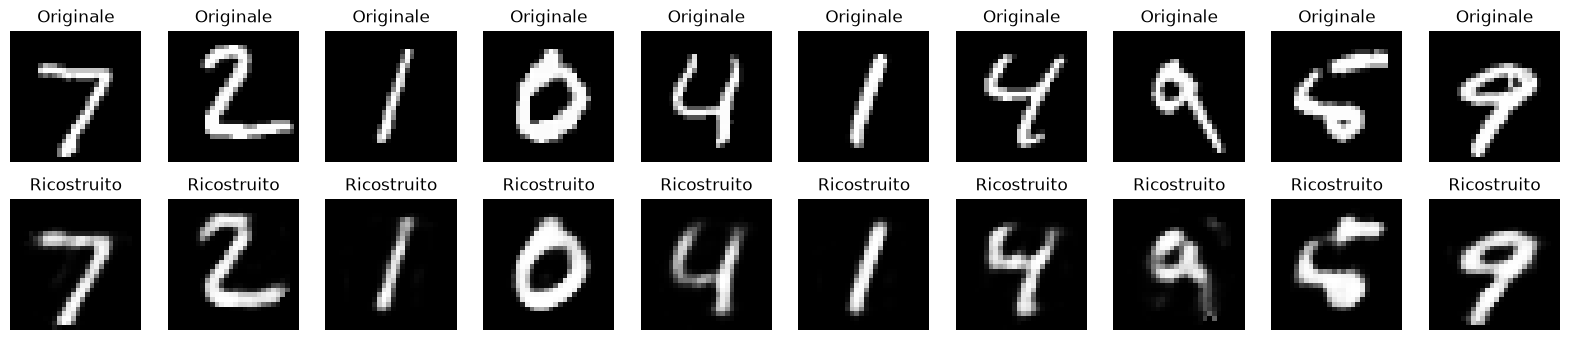

In [1]:
import os

# Configurazione del backend di Keras.
# In questo caso viene impostato PyTorch come motore di calcolo numerico prima di importare Keras.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. PREPARAZIONE DEL DATASET
# =============================================================================

# Carichiamo il dataset MNIST (cifre scritte a mano). 
# Poiché l'autoencoder è un modello di apprendimento non supervisionato (ricostruisce l'input), 
# ignoriamo le etichette di classificazione (indicate con _).
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalizzazione dei dati: i valori dei pixel originari sono tra 0 e 255.
# Portandoli nell'intervallo [0, 1] facilitiamo la convergenza del gradiente durante l'addestramento.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Operazione di 'Flattening': trasformiamo ogni immagine 28x28 in un vettore lineare di 784 elementi.
# Questo è necessario perché utilizzeremo strati Dense (completamente connessi) che accettano input piatti.
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

# =============================================================================
# 2. DEFINIZIONE DELL'ARCHITETTURA DELL'AUTOENCODER
# =============================================================================

input_dim = 784    # Dimensione originale (28*28)
latent_dim = 32   # Dimensione dello spazio latente (collo di bottiglia)

# --- ENCODER (Compressione) ---
# L'Encoder riceve l'immagine piatta e ne riduce progressivamente la dimensionalità.
inputs = keras.Input(shape=(input_dim,), name="Input_Immagine")
x = layers.Dense(128, activation="relu")(inputs)

# Lo strato Bottleneck rappresenta l' "essenza" compressa del dato originale.
# Qui forziamo la rete a imparare le caratteristiche più importanti per poter ricostruire l'input iniziale.
latent = layers.Dense(latent_dim, activation="relu", name="Bottleneck")(x)

# --- DECODER (Ricostruzione) ---
# Il Decoder riceve la rappresentazione compressa e cerca di espanderla per tornare alla forma originale.
x = layers.Dense(128, activation="relu")(latent)

# Lo strato di output utilizza l'attivazione 'sigmoid' per garantire che i valori dei pixel
# ricostruiti siano compresi tra 0 e 1, coerentemente con i dati di input normalizzati.
outputs = layers.Dense(input_dim, activation="sigmoid", name="Ricostruzione")(x)

# Creazione del modello completo che collega input e output.
autoencoder = keras.Model(inputs=inputs, outputs=outputs, name="Autoencoder_Hourglass")

# =============================================================================
# 3. COMPILAZIONE E ADDESTRAMENTO
# =============================================================================

# Utilizziamo l'ottimizzatore Adam e la funzione di perdita MSE (Mean Squared Error).
# L'obiettivo è minimizzare la differenza quadratica tra l'immagine originale e quella ricostruita.
autoencoder.compile(optimizer="adam", loss="mse")

print("Inizio fase di addestramento: il modello imparerà a ricostruire le immagini minimizzando l'errore...")
# Durante il fit, passiamo x_train sia come input che come target, poiché vogliamo che l'output sia uguale all'input.
autoencoder.fit(
    x_train, 
    x_train, 
    epochs=10, 
    batch_size=256, 
    validation_data=(x_test, x_test), 
    verbose=1
)

# =============================================================================
# 4. VALIDAZIONE E VISUALIZZAZIONE DEI RISULTATI
# =============================================================================

# Utilizziamo il modello addestrato per ricostruire le prime 10 immagini del set di test.
decoded_imgs = autoencoder.predict(x_test[:10], verbose=0)

# Keras con backend PyTorch restituisce tensori. Per visualizzarli con Matplotlib,
# dobbiamo convertirli in array NumPy. La funzione ops.convert_to_numpy gestisce 
# correttamente l'eventuale spostamento da memoria GPU a CPU.
decoded_imgs_np = ops.convert_to_numpy(decoded_imgs)
x_test_np = x_test[:10]

# Creazione della griglia di visualizzazione per confrontare input e output.
plt.figure(figsize=(20, 4))
for i in range(10):
    # Visualizzazione dell'immagine originale
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_np[i].reshape(28, 28), cmap="gray")
    plt.title("Originale")
    plt.axis("off")

    # Visualizzazione dell'immagine ricostruita dal decoder
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs_np[i].reshape(28, 28), cmap="gray")
    plt.title("Ricostruito")
    plt.axis("off")

plt.show()